# Bayesian Optimization

This notebook performs batch Bayesian optimization (BO) over a constrained ternary mixture space, where decision variables are reagent dispensing volumes in mL:

- x = [Co, MIM, TEA] (mL)
- Constraint: Co + MIM + TEA = total_ml (default: 8.0 mL)
- Discrete lattice: step_ml (default: 0.1 mL)
- Objective: y is treated as a scalar to maximize.

**Workflow:**
1.  **Definition** Define a constrained ternary composition space under a fixed total volume constraint.
2.  **Model:** Fit a Gaussian Process to existing experimental data.
3.  **Acquisition** Calculate Expected Improvement (EI) across a discrete lattice of feasible points. 
4.  **Selection** Select the next best batch of experiments using a greedy EI strategy with local penalization.
5.  **Execution** Execute the proposed experiments and append the measured responses to the dataset for subsequent BO iterations.

### Imports

In [1]:
from typing import Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from matplotlib.colors import PowerNorm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import ternary
from scipy.stats import norm


## 1. Definition
Helper functions for coordinate transformation (Ternary $\to$ Cartesian), unit scaling, and the Acquisition Function (EI).

In [2]:
# ---------- scaling ----------
def unit_scale(X: np.ndarray, bounds: Sequence[Tuple[float, float]]):
    """Scales input X to the [0, 1] range based on provided bounds."""
    X = np.asarray(X, float)
    lo = np.array([b[0] for b in bounds], float)
    hi = np.array([b[1] for b in bounds], float)
    w = hi - lo
    if np.any(w <= 0):
        raise ValueError("Invalid bounds.")
    return (X - lo) / w, lo, hi


In [3]:
# ----------  map (Co, MIM, TEA) to ternary XY coordinates ----------
def ternary_to_xy_lrt(lrt_ml: np.ndarray):
    # l=Co (left), r=MIM (right), t=TEA (top); l+r+t = scale (mL)
    lrt = np.asarray(lrt_ml, float)
    x = lrt[:, 1] + 0.5 * lrt[:, 2]          # x = r + t/2
    y = (np.sqrt(3) / 2.0) * lrt[:, 2]       # y = (√3/2) * t
    return np.column_stack([x, y])

In [4]:
# ---------- generate feasible lattice (Co, MIM, TEA) ----------
def build_feasible_lattice(total_ml=8.0, step_ml=0.1, min_co=0.1, min_mim=0.1, min_tea=0.0):
    # Enumerate Co and MIM on the grid; TEA is determined by mass balance.
    grid_vals = np.round(np.arange(0.0, total_ml + 1e-9, step_ml), 10)
    pts = []
    for co in grid_vals:
        for mim in grid_vals:
            tea = total_ml - co - mim
            # tea must lie on the grid too
            if tea < -1e-9:
                continue
            tea = np.round(tea, 10)
            # enforce on-grid (multiple of step)
            if abs(tea/step_ml - np.round(tea/step_ml)) > 1e-9:
                continue
            # lower bounds
            if co >= min_co - 1e-9 and mim >= min_mim - 1e-9 and tea >= min_tea - 1e-9:
                pts.append((co, mim, tea))
    return np.array(pts, dtype=float)




## 2. Model: Gaussian Process
We model the objective function $f(x)$ using a Gaussian Process with a **Matern Kernel** (handles non-smooth variations) and a **White Kernel** (handles experimental noise).


In [5]:
# ---------- Gaussian process ----------
def fit_gp(X: np.ndarray, y: np.ndarray, bounds: Sequence[Tuple[float, float]],
           normalise_y: bool = True, n_restarts: int = 20, random_state: int = 42):
    """
    Fit a Gaussian Process (GP) model using a Matern(ν=2.5, ARD) kernel and
    white-noise term. 

    Parameters
    ----------
    X : (n_samples, n_features)
        Input variables (e.g. [Co, MIM, TEA] in mL).
    y : (n_samples,)
        Observed scalar responses.
    bounds : list of (low, high)
        Physical range for each variable; used for unit scaling to [0, 1].
    normalise_y : bool, default True
        Whether to z-score y for numerical stability.
    n_restarts : int, default 20
        Number of random restarts for hyperparameter optimisation.
    random_state : int, default 42
        Random seed for reproducibility.

    Returns
    -------
    fit : dict
        Contains fitted GP model, scaled inputs, bounds, and y-scaler.
    info : dict
        Diagnostic information: negative log-likelihood, kernel parameters, etc.
    """
    X = np.asarray(X, float)
    y = np.asarray(y, float).ravel()

    # --- shape validation ---
    if X.ndim != 2 or len(bounds) != X.shape[1] or len(y) != len(X):
        raise ValueError("Shape mismatch between X, y, and bounds.")

    # --- scaling ---
    Xu, lo, hi = unit_scale(X, bounds)

    # --- normalise y ---
    if normalise_y:
        ys = StandardScaler(with_mean=True, with_std=True)
        yp = ys.fit_transform(y.reshape(-1, 1)).ravel()
    else:
        ys = None
        yp = y.copy()

    # --- kernel ---
    
    k = (C(1.0, (0.1, 10))
        * Matern(length_scale=[0.5]*X.shape[1], length_scale_bounds=(0.05, 1.0), nu=2.5)
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-2))
        )
    # --- GP fitting ---
    gp = GaussianProcessRegressor(
        kernel=k,
        normalize_y=False,
        n_restarts_optimizer=int(n_restarts),
        random_state=int(random_state)
    )
    gp.fit(Xu, yp)

    # --- diagnostics ---
    info = {
        "nll": float(-gp.log_marginal_likelihood_value_),
        "kernel_": str(gp.kernel_),
        "y_mean": None if ys is None else float(ys.mean_[0]),
        "y_std": None if ys is None else float(ys.scale_[0]),
    }
    fit = {
        "gp": gp, "Xu": Xu, "yproc": yp,
        "bounds": bounds, "lo": lo, "hi": hi, "yscaler": ys
    }
    return fit, info


## 3. Acquisition: Expected Improvement

We evaluate the **Expected Improvement (EI)** acquisition function across the entire **discrete feasible lattice** (all valid combinations of Co, mIm, and TEA).

The EI score balances two competing goals:
* **Exploitation:** Targeting high predicted values (high $\mu$).
* **Exploration:** Targeting high uncertainty (high $\sigma$) to reduce model error.

$$EI(x) = (\mu(x) - y_{best} - \xi)\Phi(Z) + \sigma(x)\phi(Z)$$

* **$\xi$ (xi):** A trade-off parameter (default 0.01). Higher values encourage more exploration.

In [6]:
# ---- EI for maximisation ----
def compute_ei(mu: np.ndarray, sigma: np.ndarray, y_best: float, xi: float = 0.01):
    """
    Expected Improvement (EI) for maximisation.
    EI = (mu - y_best - xi) * Phi(z) + sigma * phi(z),  z = (mu - y_best - xi) / sigma.
    sigma == 0 -> EI = 0 to avoid division by zero.
    """
    mu = np.asarray(mu, float).ravel()
    sigma = np.asarray(sigma, float).ravel()
    improv = mu - (float(y_best) + float(xi))
    z = np.zeros_like(mu)
    mask = sigma > 0
    z[mask] = improv[mask] / sigma[mask]
    ei = np.zeros_like(mu)
    ei[mask] = improv[mask] * norm.cdf(z[mask]) + sigma[mask] * norm.pdf(z[mask])
    ei[~mask] = 0.0
    ei[ei < 0] = 0.0  # numerical safety
    return ei

In [7]:
# ---- get best observed y on original scale from fit ----
def y_best_from_fit(fit: dict):
    yp = np.asarray(fit["yproc"], float)
    s = fit["yscaler"]
    return float(yp.max()) if s is None else float(s.inverse_transform(yp.reshape(-1,1)).ravel().max())


In [8]:

def lattice_mu_sigma_ei(fit: dict, bounds, total_ml: float = 8.0, step_ml: float = 0.1, xi: float = 0.01):
    """Compute lattice (in mL), unit inputs, predictive mean/std and EI once; reuse for plotting and selection."""
    lattice = build_feasible_lattice(total_ml=total_ml, step_ml=step_ml)  # (Co, MIM, TEA) in mL
    Xu, _, _ = unit_scale(lattice, bounds)
    mu, sd = fit["gp"].predict(Xu, return_std=True)
    if fit["yscaler"] is not None:
        mu = fit["yscaler"].inverse_transform(mu.reshape(-1,1)).ravel()
        sd  = sd * float(fit["yscaler"].scale_[0])
    ei = compute_ei(mu, sd, y_best=y_best_from_fit(fit), xi=xi)
    return lattice, Xu, mu.ravel(), sd.ravel(), ei.ravel()

## 4. Selection
To select a batch of $k$ experiments, we use a **Greedy Strategy with Local Penalization**:
1. Select the point with the highest EI.
2. "Penalize" (zero out) the EI of neighbors within a radius `radius_uc`.
3. Repeat until $k$ points are found.

*This prevents the algorithm from selecting multiple effectively identical points in one batch.*

In [9]:
# ---- simple local penalisation in unit space to diversify a batch ----

def greedy_ei_with_radius(lattice, Xu, ei, X_seen=None, step_ml=0.1, k=5, radius_uc=0.20):
    """
    Greedy top-k selection on a discrete lattice with local penalisation in unit space.
    After each pick, zero EI within an L2 ball of radius `radius_uc`.
    """
    ei_work = ei.copy()

    # Mask historical points
    if X_seen is not None and len(X_seen) > 0:
        Xs = np.round(np.asarray(X_seen, float) / step_ml) * step_ml
        seen = {tuple(r) for r in Xs}
        for i, row in enumerate(np.round(lattice / step_ml) * step_ml):
            if tuple(row) in seen:
                ei_work[i] = 0.0

    picked_idx = []

    # Iterative greedy selection
    for _ in range(int(k)):
        i = int(np.argmax(ei_work))
        if not np.isfinite(ei_work[i]) or ei_work[i] <= 0:
            break
        picked_idx.append(i)
        di = np.linalg.norm(Xu - Xu[i], axis=1)
        ei_work[di <= float(radius_uc)] = 0.0

    return picked_idx



## 5. Execution

In [10]:
# ---------- visualization ----------
def plot_sampling_space(scale_ml: float = 8.0):
    s = int(round(scale_ml))  # 8
    fig, tax = ternary.figure(scale=s)
    tax.gridlines(multiple=1, color="0.8", linewidth=0.8, zorder=0)  # 1 mL grid
    tax.boundary(linewidth=2.0, zorder=0)
    tax.left_corner_label("", offset=0)

    # Add a manually positioned label (Co2+)
    tax.annotate(
        r"Co$^{2+}$ (mL)",
        position=(0, 1, 0),            # bottom-left vertex (Co2+=0, 2-mIm=8, TEA=0)
        fontsize=14,
        textcoords="offset points",
        xytext=(-35,-60),
        ha='center', va='center'
    )

    # tax.right_corner_label("2-mIm (mL)", fontsize=14, offset=0.4)
    tax.right_corner_label("", offset=0)
    tax.annotate(
        r"2-mIm (mL)",
        position=(0, 1, 0),
        fontsize=14,
        xytext=(315, -60),
        textcoords="offset points",
        ha='center', va='center'
    )

    tax.top_corner_label("TEA (mL)", fontsize=14, offset=0.2)
    
    tax.ticks(axis='lbr', multiple=1, linewidth=1,
              tick_formats="%d", fontsize=12, offset=0.015)
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')
    plt.tight_layout()
    return tax, s

def plot_initial_samples(tax, X_ml: np.ndarray, marker_size: float = 60, marker_color: str = "red"):
    X_ml = np.asarray(X_ml, float)
    ternary_pts = [(row[1], row[2], row[0]) for row in X_ml]  # (MIM, TEA, Co)
    for p in ternary_pts:
        tax.scatter([p], marker='o', color=marker_color, s=marker_size,
                    edgecolors=marker_color, facecolors='none', vmin=None, vmax=None)



In [11]:
def select_and_plot_next_batch(X, y, bounds, k=5, xi=0.01,
                               total_ml=8.0, step_ml=0.1,
                               radius_uc=0.2, random_state=42):
    """
    Fit a GP, compute EI on the feasible lattice once, select a diversified batch
    using greedy local penalisation, draw the EI heatmap with suggested stars,
    and return X_next plus a small statistics table.
    """
    # Fit GP 
    fit, info = fit_gp(X, y, bounds, normalise_y=True, n_restarts=10, random_state=random_state)

    # Compute lattice + EI 
    lattice, Xu, mu, sd, ei = lattice_mu_sigma_ei(fit, bounds, total_ml=total_ml, step_ml=step_ml, xi=xi)

    # Greedy selection with unit-space radius
    idx = greedy_ei_with_radius(lattice, Xu, ei, X_seen=X, step_ml=step_ml, k=k, radius_uc=radius_uc)
    X_next = lattice[idx] if idx else np.empty((0,3), float)

    # Plot EI heatmap using the same EI used for selection (consistency)
    tax, _ = plot_sampling_space(scale_ml=total_ml)
    lrt = lattice[:, [0,1,2]]
    XY  = ternary_to_xy_lrt(lrt)
    tri = Triangulation(XY[:,0], XY[:,1])
    ax  = tax.get_axes()
    tpc = ax.tripcolor(tri, ei, shading="gouraud", zorder=1)
    cbar = plt.colorbar(tpc, ax=ax, fraction=0.046, pad=0.04, shrink=0.9, anchor=(0.0, 1))
    cbar.set_label("Expected Improvement")
    tax.boundary(linewidth=2.0, zorder=3)

    # Overlay existing samples (red circles) and the new suggestions (yellow stars)
    plot_initial_samples(tax, X)
    if X_next.size:
        pts = [(r[1], r[2], r[0]) for r in X_next]
        tax.scatter(pts, marker='*', s=130, edgecolor='k', facecolor='yellow', linewidths=0.8, zorder=5)

    # Small table (for logging or CSV saving elsewhere)
    if X_next.size:
        table = {
            "Co_mL": X_next[:,0], "MIM_mL": X_next[:,1], "TEA_mL": X_next[:,2],
            "mu": mu[idx], "sigma": sd[idx], "EI": ei[idx]
        }
    else:
        table = {"Co_mL":[], "MIM_mL":[], "TEA_mL":[], "mu":[], "sigma":[], "EI":[]}

    return X_next, table, (fit, info, (lattice, mu, sd, ei))


In [ ]:
def select_and_plot_next_batch_2d(X, y, k=5, xi=0.01,
                                  total_ml=8.0, step_ml=0.1,
                                  radius_uc=0.2, random_state=42):
    lattice = build_feasible_lattice(total_ml=total_ml, step_ml=step_ml)
    lattice_2d = lattice[:, :2]
    X_2d = np.asarray(X, float)[:, :2]
    bounds_2d = [(0.0, total_ml)] * 2

    fit, info = fit_gp(X_2d, y, bounds_2d, normalise_y=True, n_restarts=10, random_state=random_state)

    Xu, _, _ = unit_scale(lattice_2d, bounds_2d)
    mu, sd = fit["gp"].predict(Xu, return_std=True)
    if fit["yscaler"] is not None:
        mu = fit["yscaler"].inverse_transform(mu.reshape(-1, 1)).ravel()
        sd = sd * float(fit["yscaler"].scale_[0])
    ei = compute_ei(mu, sd, y_best=float(y.max()), xi=xi)

    idx = greedy_ei_with_radius(lattice, Xu, ei, X_seen=X, step_ml=step_ml, k=k, radius_uc=radius_uc)
    X_next = lattice[idx] if idx else np.empty((0, 3), float)

    tax, _ = plot_sampling_space(scale_ml=total_ml)
    XY = ternary_to_xy_lrt(lattice)
    tri = Triangulation(XY[:, 0], XY[:, 1])
    ax = tax.get_axes()
    tpc = ax.tripcolor(tri, ei, shading="gouraud", zorder=1)
    cbar = plt.colorbar(tpc, ax=ax, fraction=0.046, pad=0.04, shrink=0.9, anchor=(0.0, 1))
    cbar.set_label("Expected Improvement (2D)")
    tax.boundary(linewidth=2.0, zorder=3)
    plot_initial_samples(tax, X)
    if X_next.size:
        pts = [(r[1], r[2], r[0]) for r in X_next]
        tax.scatter(pts, marker='*', s=130, edgecolor='k', facecolor='yellow', linewidths=0.8, zorder=5)

    if X_next.size:
        table = {"Co_mL": X_next[:, 0], "MIM_mL": X_next[:, 1], "TEA_mL": X_next[:, 2],
                 "mu": mu[idx], "sigma": sd[idx], "EI": ei[idx]}
    else:
        table = {"Co_mL": [], "MIM_mL": [], "TEA_mL": [], "mu": [], "sigma": [], "EI": []}

    return X_next, table, (fit, info, (lattice, mu, sd, ei))

In [12]:
def append_batch(X: np.ndarray, y: np.ndarray, X_new: np.ndarray, y_new: np.ndarray):
    """
    Concatenate arrays after a batch is executed experimentally.
    Shapes: X (n,3), y (n,), X_new (m,3), y_new (m,).
    """
    if X_new.size == 0:
        return X, y
    X_all = np.vstack([X, X_new])
    y_all = np.concatenate([y, y_new.ravel()])
    return X_all, y_all

## BO execution log

Each round follows:
- Call `select_and_plot_next_batch(...)` to generate `X_next` and a proposal table.
- Execute the experiments.
- Enter the measured responses as `y_next`.
- Call `append_batch(...)` to update the dataset.


In [13]:
# --- Setup Data ---
# X: [Co, MIM, TEA] in mL
X = np.array([
    [0.4, 4.9, 2.7],
    [7.9, 0.1, 0.0],
    [0.1, 0.1, 7.8],
    [3.8, 0.5, 3.7],
    [4.3, 3.7, 0.0],
], float)

y = np.array([0.02616, 0.0, 0.0, 0.0, 0.028653], float)

bounds = [(0.0, 8.0), (0.0, 8.0), (0.0, 8.0)]

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed next batch:
1: Co=0.1, MIM=3.5, TEA=4.4 | mu=0.0234, sigma=0.0075, EI=5.71e-05
2: Co=1.4, MIM=6.6, TEA=0.0 | mu=0.0171, sigma=0.0095, EI=3.74e-05
3: Co=1.3, MIM=3.4, TEA=3.3 | mu=0.0248, sigma=0.0065, EI=3.71e-05
4: Co=0.1, MIM=6.9, TEA=1.0 | mu=0.0158, sigma=0.0098, EI=3.40e-05
5: Co=2.6, MIM=5.4, TEA=0.0 | mu=0.0240, sigma=0.0063, EI=2.15e-05


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


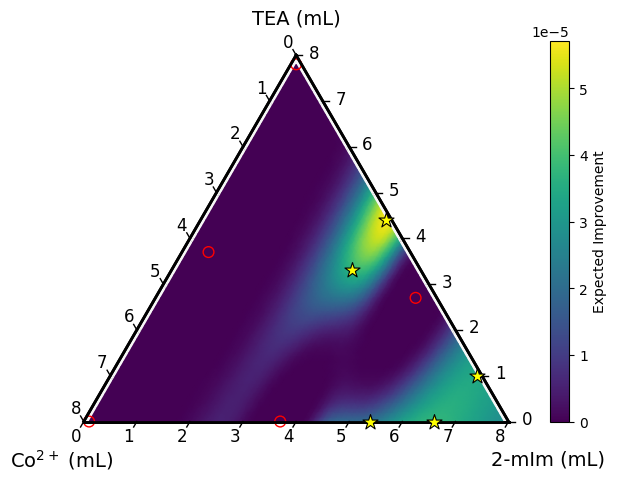

In [14]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=5, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 1

In [15]:
y_next = np.array([0.000565,0.012749,0.027947,0,0.027005], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


Proposed next batch:
1: Co=3.6, MIM=4.0, TEA=0.4 | mu=0.0252, sigma=0.0092, EI=2.92e-04
2: Co=1.9, MIM=3.3, TEA=2.8 | mu=0.0233, sigma=0.0098, EI=2.46e-04
3: Co=0.1, MIM=4.7, TEA=3.2 | mu=0.0254, sigma=0.0087, EI=2.35e-04
4: Co=4.6, MIM=2.7, TEA=0.7 | mu=0.0181, sigma=0.0117, EI=1.86e-04
5: Co=3.2, MIM=2.3, TEA=2.5 | mu=0.0146, sigma=0.0125, EI=1.28e-04


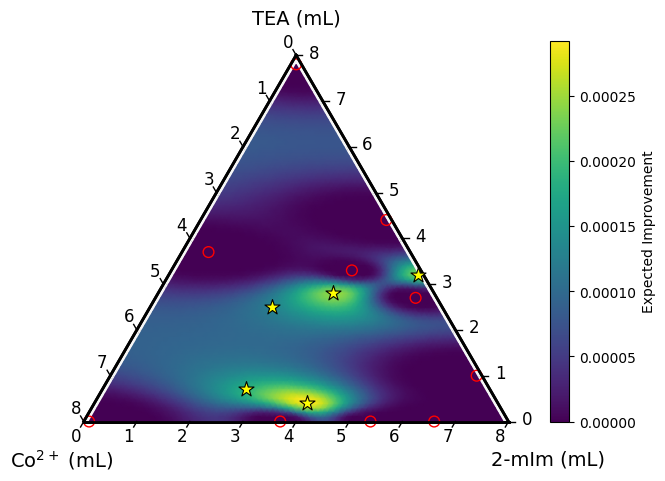

In [16]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=5, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 2

In [17]:
y_next = np.array([0.026131,0.061259,0.018488,0.02566,0.040154], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed next batch:
1: Co=2.0, MIM=3.6, TEA=2.4 | mu=0.0516, sigma=0.0105, EI=1.23e-04
2: Co=2.8, MIM=2.3, TEA=2.9 | mu=0.0456, sigma=0.0096, EI=1.08e-05
3: Co=3.3, MIM=3.1, TEA=1.6 | mu=0.0246, sigma=0.0161, EI=8.58e-06
4: Co=5.9, MIM=0.2, TEA=1.9 | mu=0.0201, sigma=0.0171, EI=6.74e-06
5: Co=1.2, MIM=4.9, TEA=1.9 | mu=0.0243, sigma=0.0157, EI=6.25e-06


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


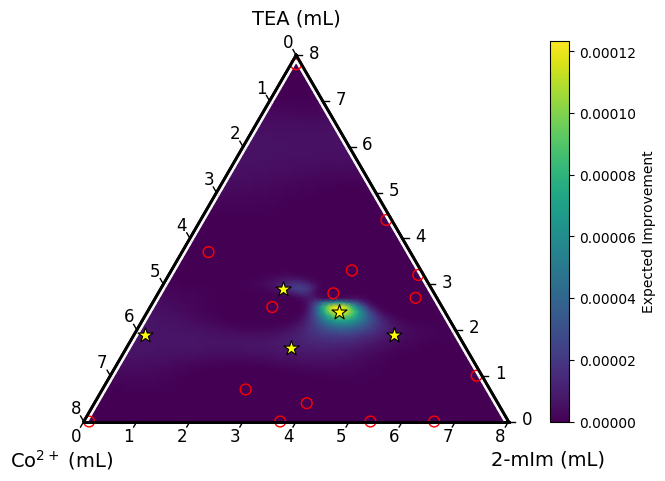

In [18]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=5, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 3

In [19]:
y_next = np.array([0.064853,0.046449,0.018542,0.0,0.001001], float)
X, y = append_batch(X, y, X_next, y_next)

Proposed next batch:
1: Co=2.3, MIM=3.2, TEA=2.5 | mu=0.0660, sigma=0.0044, EI=3.34e-05
2: Co=2.1, MIM=0.1, TEA=5.8 | mu=0.0193, sigma=0.0193, EI=1.10e-05
3: Co=0.9, MIM=1.2, TEA=5.9 | mu=0.0187, sigma=0.0192, EI=9.68e-06
4: Co=0.1, MIM=2.5, TEA=5.4 | mu=0.0151, sigma=0.0184, EI=2.91e-06
5: Co=2.0, MIM=1.3, TEA=4.7 | mu=0.0128, sigma=0.0184, EI=1.76e-06


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


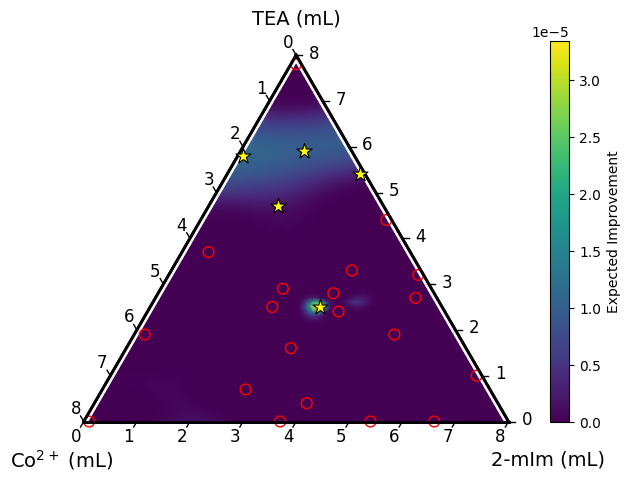

In [20]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=5, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 4

In [21]:
y_next = np.array([0.118373,0,0.000066,0,0.043533], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed next batch:
1: Co=2.3, MIM=2.7, TEA=3.0 | mu=0.1099, sigma=0.0110, EI=2.17e-04
2: Co=2.4, MIM=3.8, TEA=1.8 | mu=0.0932, sigma=0.0145, EI=3.61e-05


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


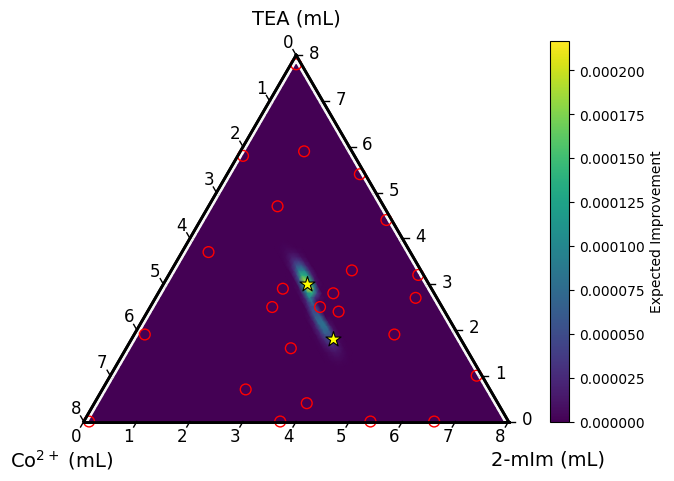

In [22]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=2, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 5

In [23]:
y_next = np.array([2.333737,0.056292], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed next batch:
1: Co=1.9, MIM=2.8, TEA=3.3 | mu=2.2236, sigma=0.1817, EI=2.77e-02
2: Co=0.7, MIM=2.9, TEA=4.4 | mu=1.2543, sigma=0.4197, EI=6.23e-04


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


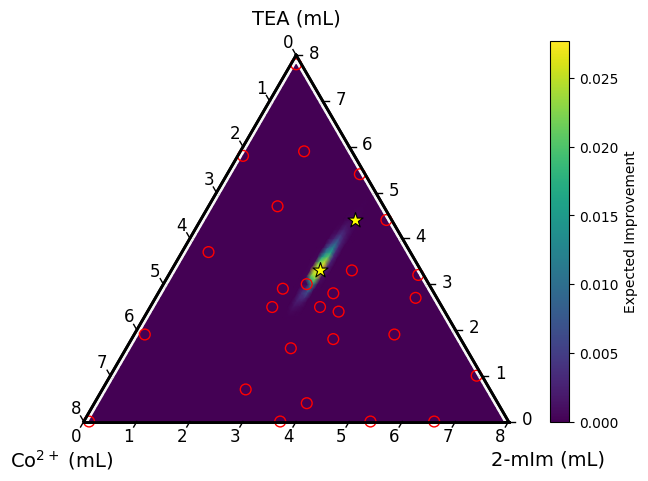

In [24]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=2, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: rounds 6

In [25]:
y_next = np.array([1.742844,0.417868], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed next batch:
1: Co=2.5, MIM=2.7, TEA=2.8 | mu=2.2749, sigma=0.1041, EI=1.59e-02
2: Co=0.1, MIM=7.9, TEA=0.0 | mu=0.1676, sigma=0.5971, EI=1.94e-05


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


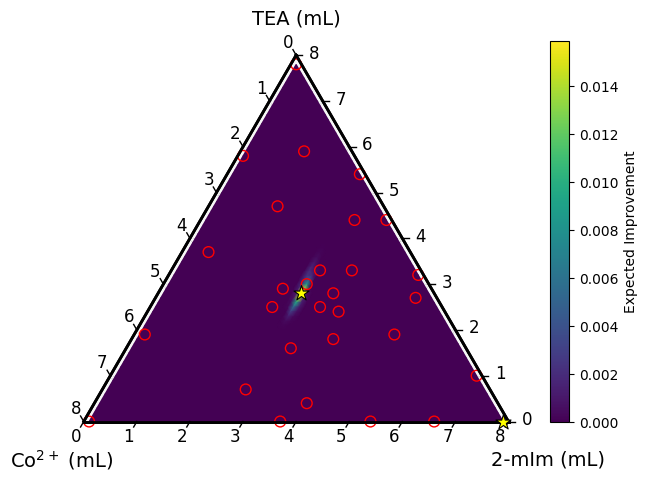

In [26]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=2, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 7

In [27]:
y_next = np.array([1.94775,0.0], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed next batch:
1: Co=2.2, MIM=2.7, TEA=3.1 | mu=2.3008, sigma=0.0938, EI=1.98e-02
2: Co=1.3, MIM=2.3, TEA=4.4 | mu=0.6026, sigma=0.4703, EI=1.21e-05


c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


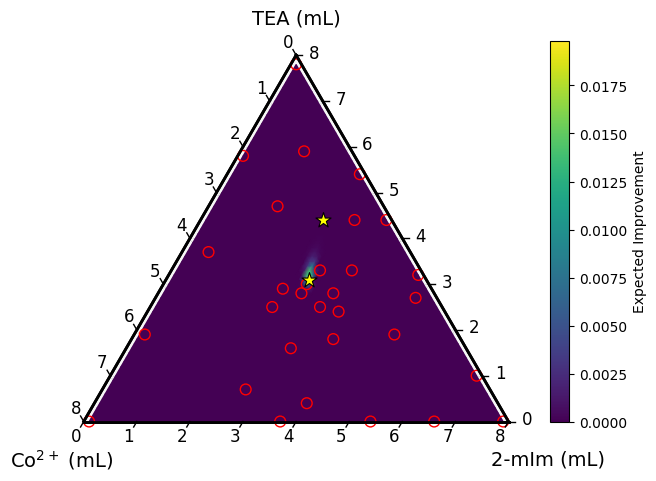

In [28]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=2, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## BO: round 8

In [29]:
y_next = np.array([0.414595,0.0], float)
X, y = append_batch(X, y, X_next, y_next)

c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yezuy\miniconda3\Lib\site-packages\sklearn\gaussian_process\kernels

Proposed next batch:
1: Co=2.4, MIM=2.7, TEA=2.9 | mu=2.8021, sigma=0.1782, EI=4.59e-01
2: Co=1.1, MIM=3.0, TEA=3.9 | mu=0.3640, sigma=1.0346, EI=1.10e-02


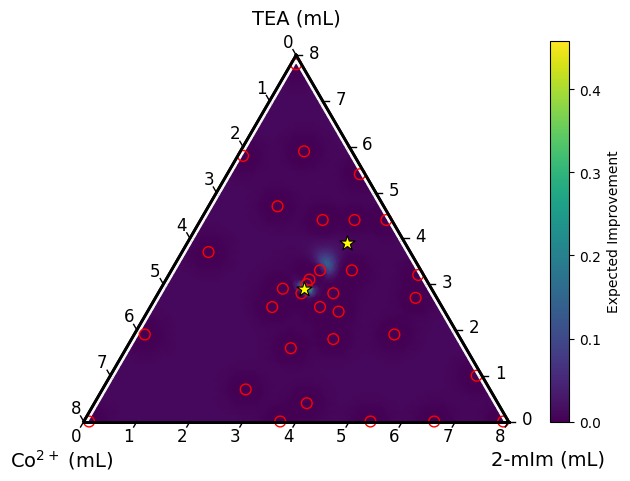

In [30]:
X_next, table, cache = select_and_plot_next_batch(
    X, y, bounds,
    k=2, xi=0.01,
    total_ml=8.0, step_ml=0.1,
    radius_uc=0.2,          
    random_state=42
)
print("Proposed next batch:")
for i in range(len(table["Co_mL"])):
    print(f"{i+1}: Co={table['Co_mL'][i]:.1f}, MIM={table['MIM_mL'][i]:.1f}, TEA={table['TEA_mL'][i]:.1f} | "
          f"mu={table['mu'][i]:.4f}, sigma={table['sigma'][i]:.4f}, EI={table['EI'][i]:.2e}")

ternary.plt.show()

## 2D Search Space (Co, MIM) — Round 0 Comparison

Since Co + MIM + TEA = 8.0 mL, TEA is fully determined by the other two variables. The 3D input space is therefore redundant — the data lies on a 2D simplex embedded in 3D. Below is a slightly more efficient alternative that fits the GP on (Co, MIM) only, eliminating the redundant dimension and giving each kernel length scale a direct physical meaning (one per reagent).

In [ ]:
X0 = np.array([
    [0.4, 4.9, 2.7],
    [7.9, 0.1, 0.0],
    [0.1, 0.1, 7.8],
    [3.8, 0.5, 3.7],
    [4.3, 3.7, 0.0],
], float)
y0 = np.array([0.02616, 0.0, 0.0, 0.0, 0.028653], float)

X_next_3d, table_3d, _ = select_and_plot_next_batch(
    X0, y0, bounds=[(0.0, 8.0)]*3,
    k=5, xi=0.01, total_ml=8.0, step_ml=0.1, radius_uc=0.2, random_state=42)
print("Round 0 \u2014 3D proposals:")
for i in range(len(table_3d["Co_mL"])):
    print(f"{i+1}: Co={table_3d['Co_mL'][i]:.1f}, MIM={table_3d['MIM_mL'][i]:.1f}, TEA={table_3d['TEA_mL'][i]:.1f} | "
          f"mu={table_3d['mu'][i]:.4f}, sigma={table_3d['sigma'][i]:.4f}, EI={table_3d['EI'][i]:.2e}")
ternary.plt.show()

X_next_2d, table_2d, _ = select_and_plot_next_batch_2d(
    X0, y0, k=5, xi=0.01, total_ml=8.0, step_ml=0.1, radius_uc=0.2, random_state=42)
print("Round 0 \u2014 2D proposals:")
for i in range(len(table_2d["Co_mL"])):
    print(f"{i+1}: Co={table_2d['Co_mL'][i]:.1f}, MIM={table_2d['MIM_mL'][i]:.1f}, TEA={table_2d['TEA_mL'][i]:.1f} | "
          f"mu={table_2d['mu'][i]:.4f}, sigma={table_2d['sigma'][i]:.4f}, EI={table_2d['EI'][i]:.2e}")
ternary.plt.show()